In [50]:
import pandas as pd
import numpy as np
import scipy
import QuantLib as ql
from dataclasses import dataclass
import copy
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
class Portfolio:

    def __init__(self):
        self.positions = []

    def add(self, instrument):
        self.positions.append(instrument)

    def value(self, market):

        total = 0

        for position in self.positions:
            total += position.price(market)

        return total

    def __repr__(self):

        output = ["Portfolio:"]

        for p in self.positions:
            output.append(f"  {p}")

        return "\n".join(output)

In [52]:
class Future:

    def __init__(self, quantity):
        self.quantity = quantity

    def price(self, market):
        return self.quantity * market.futures_price

    def __repr__(self):
        return f"Future(qty={self.quantity})"

In [53]:
class AmericanOption:

    def __init__(
        self,
        quantity,
        strike,
        expiry_days,
        option_type,
        volatility
    ):
        self.quantity = quantity
        self.strike = strike
        self.expiry_days = expiry_days
        self.option_type = option_type
        self.volatility = volatility

    def price(self, market):

        pricer = AmericanOptionPricer(
            futures_price=market.futures_price,
            strike=self.strike,
            rate=market.interest_rate,
            volatility=self.volatility,
            expiry_days=self.expiry_days,
            option_type=self.option_type
        )

        return self.quantity * pricer.price()

    def __repr__(self):

        return (
            f"AmericanOption("
            f"qty={self.quantity}, "
            f"type='{self.option_type}', "
            f"strike={self.strike}, "
            f"days={self.expiry_days}, "
            f"vol={self.volatility:.2%})"
        )

In [54]:
class AmericanOptionPricer:

    def __init__(
        self,
        futures_price,
        strike,
        rate,
        volatility,
        expiry_days,
        option_type
    ):

        self.F = futures_price
        self.K = strike
        self.r = rate
        self.vol = volatility
        self.days = expiry_days
        self.option_type = option_type.lower()

    def price(self):

        calc_date = ql.Date.todaysDate()
        ql.Settings.instance().evaluationDate = calc_date

        expiry = calc_date + self.days

        payoff = ql.PlainVanillaPayoff(
            ql.Option.Call if self.option_type == "call"
            else ql.Option.Put,
            self.K
        )

        exercise = ql.AmericanExercise(
            calc_date,
            expiry
        )

        option = ql.VanillaOption(
            payoff,
            exercise
        )

        risk_free = ql.FlatForward(
            calc_date,
            self.r,
            ql.Actual365Fixed()
        )

        vol_curve = ql.BlackConstantVol(
            calc_date,
            ql.NullCalendar(),
            self.vol,
            ql.Actual365Fixed()
        )

        process = ql.BlackProcess(                             
            ql.QuoteHandle(
                ql.SimpleQuote(self.F)
            ),
            ql.YieldTermStructureHandle(
                risk_free
            ),
            ql.BlackVolTermStructureHandle(
                vol_curve
            )
        )

        engine = ql.BaroneAdesiWhaleyApproximationEngine(
            process
        )

        option.setPricingEngine(engine)

        return option.NPV()

In [55]:
from dataclasses import dataclass

@dataclass
class Market:
    futures_price: float
    interest_rate: float

In [56]:
VOL_POINT = 0.01

BASIS_POINT = 0.0001

SPOT_BUMP = 0.001

In [57]:
class GreekEngine:

    @staticmethod
    def delta(portfolio, market):

        ds = market.futures_price * SPOT_BUMP

        up_market = copy.deepcopy(market)
        down_market = copy.deepcopy(market)

        up_market.futures_price += ds
        down_market.futures_price -= ds

        return (
            portfolio.value(up_market)
            - portfolio.value(down_market)
        ) / (2 * ds)

    @staticmethod
    def gamma(portfolio, market):

        ds = market.futures_price * SPOT_BUMP

        up_market = copy.deepcopy(market)
        down_market = copy.deepcopy(market)

        up_market.futures_price += ds
        down_market.futures_price -= ds

        up_value = portfolio.value(up_market)
        mid_value = portfolio.value(market)
        down_value = portfolio.value(down_market)

        return (
            up_value
            - 2 * mid_value
            + down_value
        ) / (ds ** 2)

    @staticmethod
    def vega(portfolio, market):

        dv = VOL_POINT

        up_portfolio = shift_portfolio_vols(portfolio, dv)
        down_portfolio = shift_portfolio_vols(portfolio, -dv)

        up_value = up_portfolio.value(market)
        down_value = down_portfolio.value(market)

        return (
            (up_value - down_value) / (2 * dv)
        ) * VOL_POINT
    
    @staticmethod
    def theta(portfolio, market):

        tomorrow = shift_time(
            portfolio,
            1
        )

        return (
            tomorrow.value(market)
            - portfolio.value(market)
        )
    
    @staticmethod
    def rho(portfolio, market):

        dr = BASIS_POINT

        up_market = copy.deepcopy(market)
        down_market = copy.deepcopy(market)

        up_market.interest_rate += dr
        down_market.interest_rate -= dr

        return (
            (portfolio.value(up_market)
            - portfolio.value(down_market))
            / (2 * dr)
        ) * BASIS_POINT
    
    @staticmethod
    def volga(portfolio, market):

        dv = VOL_POINT

        up_portfolio = shift_portfolio_vols(
            portfolio,
            dv
        )

        down_portfolio = shift_portfolio_vols(
            portfolio,
            -dv
        )

        up_value = up_portfolio.value(market)
        mid_value = portfolio.value(market)
        down_value = down_portfolio.value(market)

        return (
            (
                up_value
                - 2 * mid_value
                + down_value
            ) / (dv ** 2)
        ) * VOL_POINT
    
    @staticmethod
    def vanna_vega(portfolio, market):

        ds = market.futures_price * SPOT_BUMP

        up_market = copy.deepcopy(market)
        down_market = copy.deepcopy(market)

        up_market.futures_price += ds
        down_market.futures_price -= ds

        vega_up = GreekEngine.vega(
            portfolio,
            up_market
        )

        vega_down = GreekEngine.vega(
            portfolio,
            down_market
        )

        return (
            vega_up
            - vega_down
        ) / (2 * ds)
    
    @staticmethod
    def vanna_delta(portfolio, market):

        dv = VOL_POINT

        up_portfolio = shift_portfolio_vols(
            portfolio,
            dv
        )

        down_portfolio = shift_portfolio_vols(
            portfolio,
            -dv
        )

        delta_up = GreekEngine.delta(
            up_portfolio,
            market
        )

        delta_down = GreekEngine.delta(
            down_portfolio,
            market
        )

        return (
            delta_up
            - delta_down
        ) / (2 * dv)
    
    
    @staticmethod
    def summary(portfolio, market):

        report = GreekEngine.report(
            portfolio,
            market
        )

        for k, v in report.items():

            if k == "Value":
                print(f"{k:<25}: {v:.2f}")
            else:
                print(f"{k:<25}: {v:.4f}")

        
    @staticmethod
    def report(portfolio, market):

        return {
            "Value": portfolio.value(market),

            "Delta (ΔPnL/pt)": GreekEngine.delta(
                portfolio,
                market
            ),

            "Gamma (ΔDelta/pt)": GreekEngine.gamma(
                portfolio,
                market
            ),

            "Vega (ΔPnL/1 vol pt)": GreekEngine.vega(
                portfolio,
                market
            ),

            "Theta (ΔPnL/day)": GreekEngine.theta(
                portfolio,
                market
            ),

            "Rho (ΔPnL/bp)": GreekEngine.rho(
                portfolio,
                market
            ),

            "Volga (ΔVega/1 vol pt)": GreekEngine.volga(
                portfolio,
                market
            ),

            "Vanna-D (ΔDelta/1 vol pt)": GreekEngine.vanna_delta(
                portfolio,
                market
            ),
            
            "Vanna-V (ΔVega/pt)": GreekEngine.vanna_vega(
                portfolio,
                market
            )
        }

In [58]:
def spot_ladder(
    portfolio,
    market,
    low=-20,
    high=20,
    step=5
):

    rows = []

    current_value = portfolio.value(market)

    for pct in range(low, high + step, step):

        shocked_market = copy.deepcopy(market)

        shocked_market.futures_price = (
            market.futures_price *
            (1 + pct / 100)
        )

        value = portfolio.value(shocked_market)

        rows.append({
            "Spot Move %": pct,
            "Futures Price": shocked_market.futures_price,
            "PnL": value - current_value,
            "Portfolio Value": value,
            "Delta": GreekEngine.delta(
                portfolio,
                shocked_market
            ),
            "Gamma": GreekEngine.gamma(
                portfolio,
                shocked_market
            ),
            "Vega": GreekEngine.vega(
                portfolio,
                shocked_market
            ),
            "Vanna-V": GreekEngine.vanna_vega(
                portfolio,
                shocked_market
            ),
            "Volga": GreekEngine.volga(
                portfolio,
                shocked_market
            ),
        })

    return pd.DataFrame(rows)

In [59]:
def vol_ladder(
    portfolio,
    market,
    low=-10,
    high=10,
    step=2
):

    rows = []

    current_value = portfolio.value(market)

    for vol_shift in range(low, high + step, step):

        shocked_portfolio = shift_portfolio_vols(
            portfolio,
            vol_shift / 100
        )

        value = shocked_portfolio.value(market)

        rows.append({
            "Vol Shift (pts)": vol_shift,
            "PnL": value - current_value,
            "Portfolio Value": value,
            "Delta": GreekEngine.delta(
                shocked_portfolio,
                market
            ),
            "Gamma": GreekEngine.gamma(
                shocked_portfolio,
                market
            ),
            "Vega": GreekEngine.vega(
                shocked_portfolio,
                market
            ),
            "Volga": GreekEngine.volga(
                shocked_portfolio,
                market
            ),
            "Vanna-D": GreekEngine.vanna_delta(
                shocked_portfolio,
                market
            ),
            "Vanna-V": GreekEngine.vanna_vega(
                shocked_portfolio,
                market
            ),
        })

    return pd.DataFrame(rows)

In [60]:
def spot_vol_surface(
    portfolio,
    market,
    metric="PnL",
    spot_low=-15,
    spot_high=15,
    spot_step=3,
    vol_low=-10,
    vol_high=10,
    vol_step=2
):

    current_value = portfolio.value(market)

    spot_moves = list(
        range(
            spot_low,
            spot_high + spot_step,
            spot_step
        )
    )

    vol_moves = list(
        range(
            vol_low,
            vol_high + vol_step,
            vol_step
        )
    )

    data = []

    for spot_move in spot_moves:

        row = []

        for vol_move in vol_moves:

            shocked_market = copy.deepcopy(market)

            shocked_market.futures_price = (
                market.futures_price
                * (1 + spot_move/100)
            )

            shocked_portfolio = shift_portfolio_vols(
                portfolio,
                vol_move/100
            )

            if metric == "PnL":

                value = (
                    shocked_portfolio.value(shocked_market)
                    - current_value
                )

            elif metric == "Delta":

                value = GreekEngine.delta(
                    shocked_portfolio,
                    shocked_market
                )

            elif metric == "Gamma":

                value = GreekEngine.gamma(
                    shocked_portfolio,
                    shocked_market
                )

            elif metric == "Vega":

                value = GreekEngine.vega(
                    shocked_portfolio,
                    shocked_market
                )

            elif metric == "Volga":

                value = GreekEngine.volga(
                    shocked_portfolio,
                    shocked_market
                )

            elif metric == "Vanna-D":

                value = GreekEngine.vanna_delta(
                    shocked_portfolio,
                    shocked_market
                )

            elif metric == "Vanna-V":

                value = GreekEngine.vanna_vega(
                    shocked_portfolio,
                    shocked_market
                )

            else:
                raise ValueError(
                    f"Unknown metric: {metric}"
                )

            row.append(value)

        data.append(row)

    return pd.DataFrame(
        data,
        index=spot_moves,
        columns=vol_moves
    )

In [61]:
def shift_portfolio_vols(portfolio, dv):

    shocked = copy.deepcopy(portfolio)

    for pos in shocked.positions:

        if isinstance(pos, AmericanOption):
            pos.volatility += dv

    return shocked

In [62]:
def shift_time(portfolio, days):

    shocked = copy.deepcopy(portfolio)

    for pos in shocked.positions:

        if isinstance(pos, AmericanOption):

            pos.expiry_days = max(
                pos.expiry_days - days,
                1
            )

    return shocked

In [63]:
def plot_surface(
    portfolio,
    market,
    metric="PnL"
):

    surface = spot_vol_surface(
        portfolio,
        market,
        metric=metric
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        surface,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn" if metric=="PnL" else "coolwarm",
        center=0
    )

    plt.title(
        f"{metric} Heatmap\nSpot Move (%) vs Vol Shift (pts)"
    )

    plt.xlabel("Vol Shift (pts)")
    plt.ylabel("Spot Move (%)")

    plt.show()


In [64]:
market = Market(
    futures_price=528.75,
    interest_rate=0.038
)

market

Market(futures_price=528.75, interest_rate=0.038)

In [65]:
portfolio = Portfolio()

portfolio.add(Future(quantity=-1))

portfolio.add(
    AmericanOption(
        quantity=-5,
        strike=620,
        expiry_days=64,
        option_type="call",
        volatility=0.26189
    )
)

portfolio.add(
    AmericanOption(
        quantity=2,
        strike=530,
        expiry_days=64,
        option_type="call",
        volatility=0.2150
    )
)

print(portfolio)

Portfolio:
  Future(qty=-1)
  AmericanOption(qty=-5, type='call', strike=620, days=64, vol=26.19%)
  AmericanOption(qty=2, type='call', strike=530, days=64, vol=21.50%)


In [66]:
GreekEngine.summary(portfolio, market)

Value                    : -502.38
Delta (ΔPnL/pt)          : -0.3944
Gamma (ΔDelta/pt)        : 0.0038
Vega (ΔPnL/1 vol pt)     : 0.1015
Theta (ΔPnL/day)         : 0.0434
Rho (ΔPnL/bp)            : -0.0004
Volga (ΔVega/1 vol pt)   : -13.3067
Vanna-D (ΔDelta/1 vol pt): -4.0326
Vanna-V (ΔVega/pt)       : -0.0403


In [67]:
ladder = spot_ladder(
    portfolio,
    market,
    low=-15,
    high=15,
    step=3
)

ladder.round(3)


,Spot Move %,Futures Price,PnL,Portfolio Value,Delta,Gamma,Vega,Vanna-V,Volga
0,-15,449.438,53.952,-448.425,-0.936,0.003,0.243,0.010,2.764
1,-12,465.300,39.612,-462.765,-0.866,0.006,0.433,0.013,1.835
2,-9,481.162,26.688,-475.688,-0.758,0.008,0.627,0.010,-1.337
3,-6,497.025,15.714,-486.663,-0.623,0.009,0.716,-0.000,-6.228
4,-3,512.887,6.922,-495.455,-0.489,0.008,0.570,-0.019,-10.960
5,0,528.750,0.000,-502.377,-0.394,0.004,0.102,-0.040,-13.307
6,3,544.613,-6.015,-508.392,-0.380,-0.002,-0.691,-0.059,-12.048
7,6,560.475,-12.636,-515.012,-0.474,-0.010,-1.709,-0.068,-7.641
8,9,576.338,-21.645,-524.022,-0.681,-0.016,-2.786,-0.066,-1.841
9,12,592.200,-34.757,-537.133,-0.987,-0.022,-3.745,-0.053,3.276


In [68]:
vols = vol_ladder(
    portfolio,
    market,
    low=-10,
    high=10,
    step=2
)

vols.round(3)

,Vol Shift (pts),PnL,Portfolio Value,Delta,Gamma,Vega,Volga,Vanna-D,Vanna-V
0,-10,-7.982,-510.358,-0.077,0.027,1.452,-10.221,-1.495,-0.015
1,-8,-5.297,-507.674,-0.116,0.021,1.220,-12.801,-2.405,-0.024
2,-6,-3.122,-505.498,-0.172,0.015,0.949,-14.138,-3.113,-0.031
3,-4,-1.509,-503.886,-0.239,0.010,0.662,-14.457,-3.600,-0.036
4,-2,-0.473,-502.850,-0.315,0.007,0.376,-14.086,-3.892,-0.039
5,0,0.000,-502.377,-0.394,0.004,0.102,-13.307,-4.033,-0.040
6,2,-0.058,-502.435,-0.476,0.001,-0.155,-12.323,-4.061,-0.041
7,4,-0.609,-502.986,-0.556,-0.000,-0.391,-11.268,-4.011,-0.040
8,6,-1.611,-503.988,-0.636,-0.002,-0.606,-10.221,-3.911,-0.039
9,8,-3.022,-505.399,-0.713,-0.003,-0.800,-9.227,-3.778,-0.038


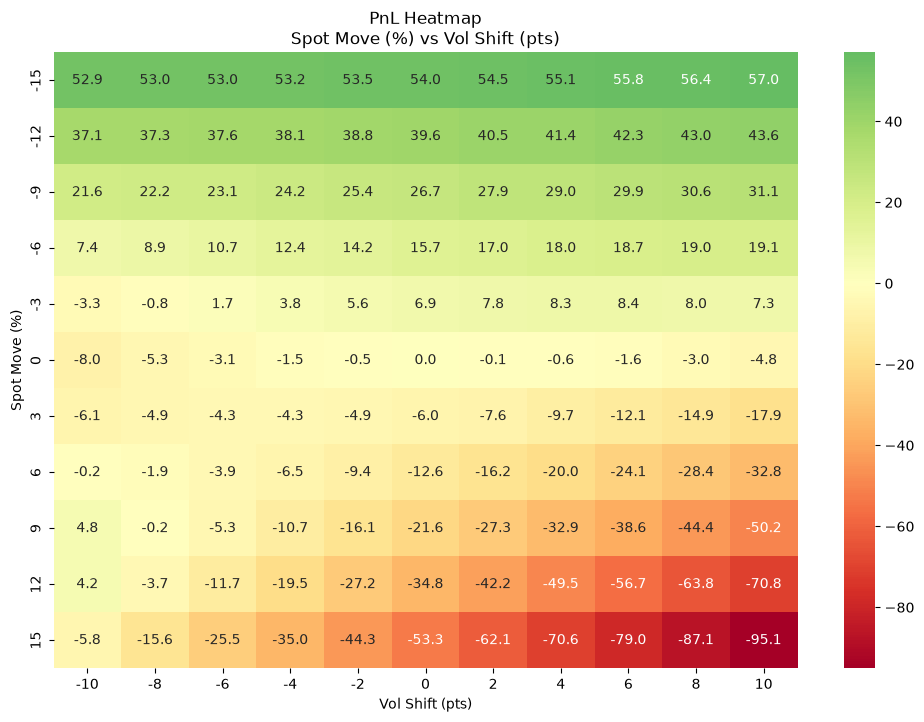

In [69]:
plot_surface(
    portfolio,
    market,
    metric="PnL"
)

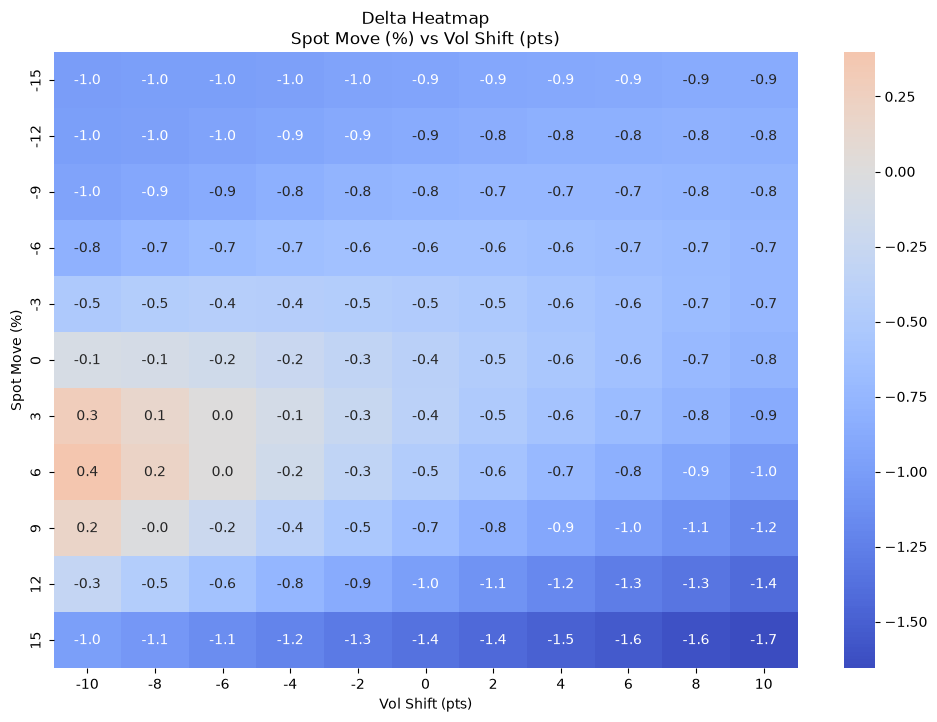

In [70]:
plot_surface(
    portfolio,
    market,
    metric="Delta"
)

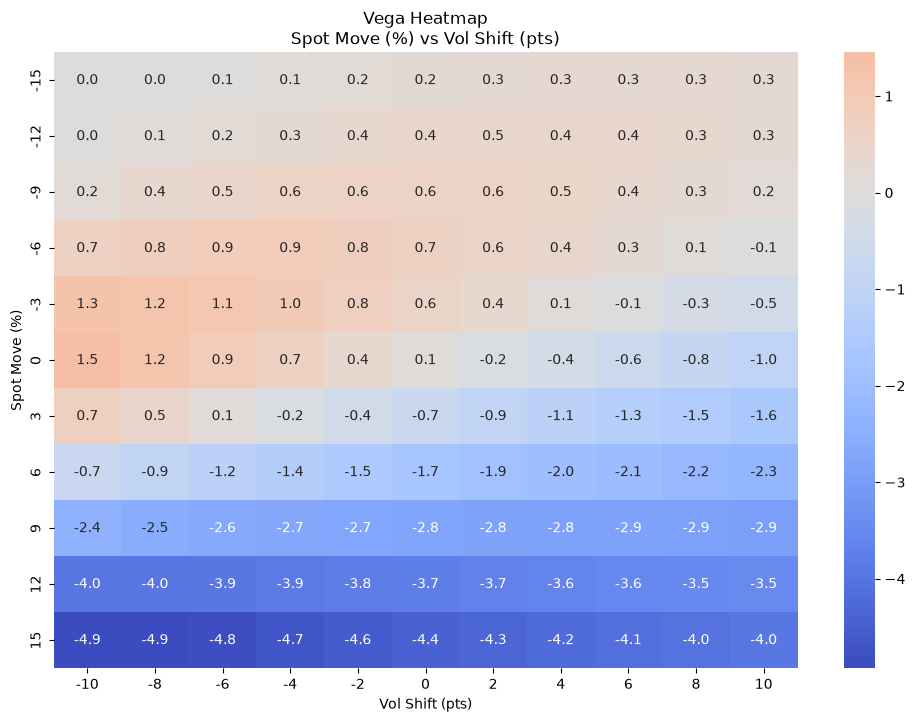

In [71]:
plot_surface(
    portfolio,
    market,
    metric="Vega"
)

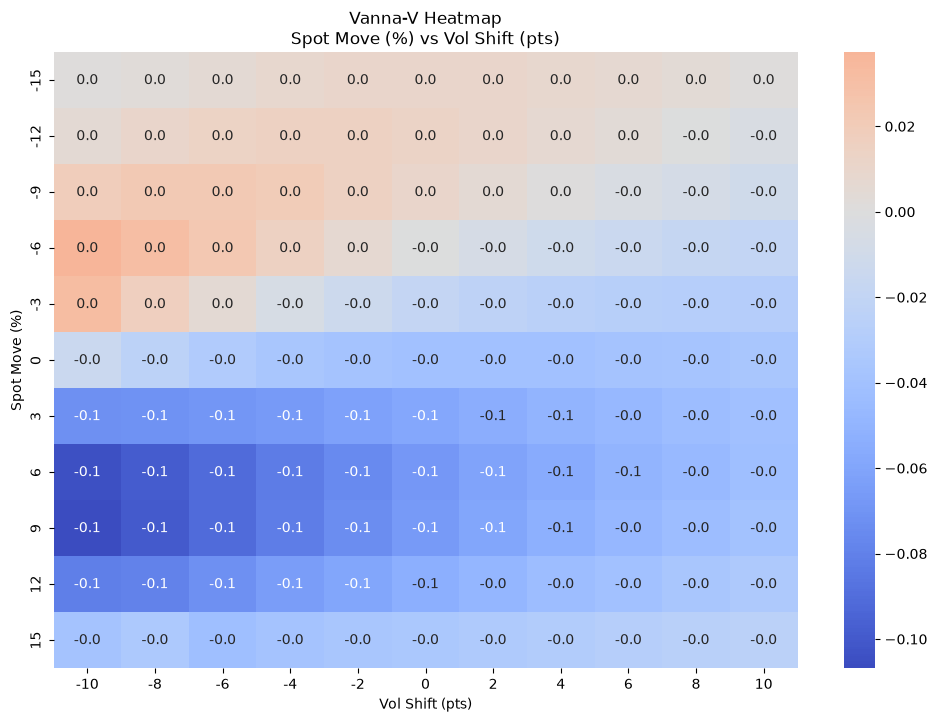

In [72]:
plot_surface(
    portfolio,
    market,
    metric="Vanna-V"
)

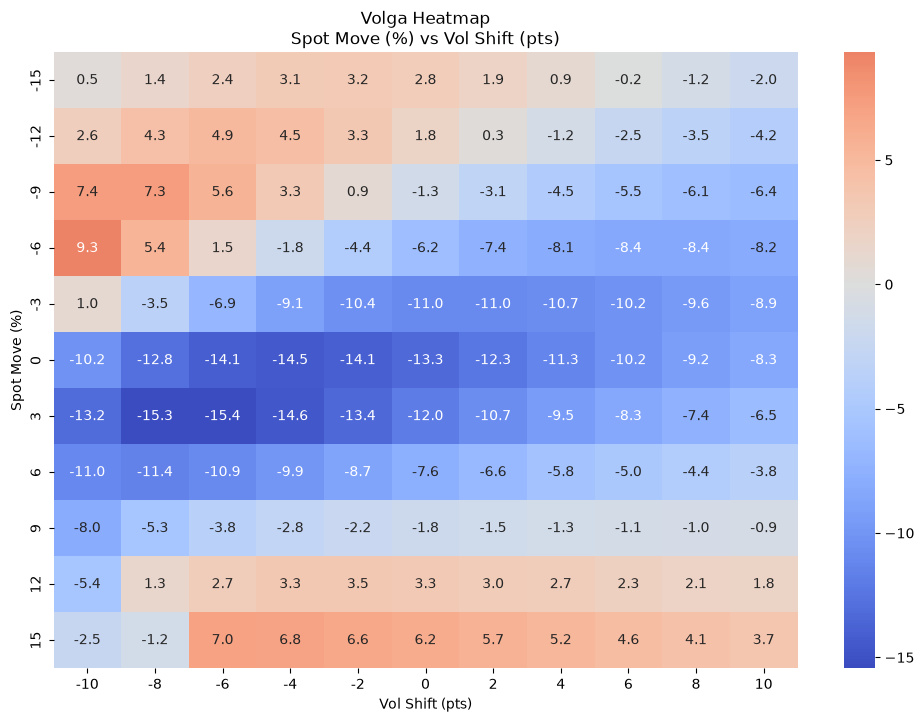

In [73]:
plot_surface(
    portfolio,
    market,
    metric="Volga"
)